This Kaggle notebook implements a complete class activity for comparing:

1. **Custom CNN**
2. **MobileNetV2 transfer learning**
3. **ResNet50 transfer learning**

The notebook also generates:

- Dataset summary
- Model architecture and parameter tables
- Accuracy and loss curves
- Confusion matrices
- Accuracy, precision, recall, and F1-score
- Training time comparison
- Grad-CAM visualizations for correct and incorrect predictions
- SHAP explanations for selected images
- Final comparative table

All figures are saved as **PDF files** and all tables are saved as **CSV files**.

In [2]:
# ============================================================
# 1. SETUP AND IMPORTS
# ============================================================

import os
import re
import time
import json
import random
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# OpenCV is useful for Grad-CAM heatmap processing.
try:
    import cv2
    CV2_AVAILABLE = True
except Exception:
    CV2_AVAILABLE = False
    print("OpenCV is not available. Grad-CAM overlay will use a fallback method.")

# SHAP is computationally heavier. The notebook will skip SHAP gracefully if unavailable.
try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False
    print("SHAP is not installed. SHAP section will be skipped gracefully.")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

2026-06-26 13:38:35.850291: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782481116.023787      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782481116.080910      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782481116.484383      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782481116.484427      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782481116.484430      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: True


In [3]:
# ============================================================
# 2. CONFIGURATION
# ============================================================

# User-provided Kaggle dataset path.
USER_DATASET_PATH = "/kaggle/input/datasets/sayalis069/mh-weed16/MH-Weed16An Indian Multiclass Annotated Weed Dataset for Computer Vision Tasks/MH-Weed16/Individual Weed Species/16 Classes of Weed_Species/Individual Weed_Species"

OUTPUT_DIR = Path("/kaggle/working/outputs")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "models"

for directory in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
FINE_TUNE_EPOCHS = 3

# Set to True if you want to fine-tune the transfer learning models after initial training.
RUN_FINE_TUNING = False

# Set to False for a faster classroom run.
RUN_SHAP = True

# Keep SHAP small because image explanations can be slow.
SHAP_BACKGROUND_IMAGES = 20
SHAP_EXPLAIN_IMAGES = 3

print("Outputs will be saved to:", OUTPUT_DIR)

Outputs will be saved to: /kaggle/working/outputs


In [4]:
# ============================================================
# 3. FIND DATASET FOLDER
# ============================================================

def list_directory_tree(root_path, max_depth=3):
    root_path = Path(root_path)
    if not root_path.exists():
        print(f"Path does not exist: {root_path}")
        return
    for path in root_path.rglob("*"):
        depth = len(path.relative_to(root_path).parts)
        if depth <= max_depth:
            print("  " * depth + "|-- " + path.name)

def find_dataset_root(possible_paths):
    for p in possible_paths:
        path = Path(p)
        if path.exists():
            # Direct match
            if any(child.is_dir() for child in path.iterdir()):
                return path

    # Fallback: search inside /kaggle/input for likely folder names
    input_root = Path("/kaggle/input")
    if input_root.exists():
        candidates = []
        for p in input_root.rglob("*"):
            if p.is_dir() and any(term in p.name.lower() for term in ["cat", "dog", "dogs", "cats"]):
                candidates.append(p)
        if candidates:
            return candidates[0]

    raise FileNotFoundError(
        "Could not locate the dataset. Please check that the Kaggle dataset is attached to this notebook."
    )

# DATASET_ROOT = find_dataset_root(USER_DATASET_PATH)
# print("Dataset root found:", DATASET_ROOT)
# print("\nDataset folder preview:")
# list_directory_tree(DATASET_ROOT, max_depth=3)

In [5]:
# divide images in training and testing groups 80:20
from pathlib import Path
import shutil

# Source dataset
source_dir = Path(USER_DATASET_PATH)

# Output folders
train_dir = Path("/kaggle/working/MH-Weed16-training")
test_dir = Path("/kaggle/working/MH-Weed16-test")

# Supported image extensions

image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

for class_folder in source_dir.iterdir():
    if not class_folder.is_dir():
        continue
    class_name = class_folder.name
    # Create class folders
    (train_dir / class_name).mkdir(parents=True, exist_ok=True)
    (test_dir / class_name).mkdir(parents=True, exist_ok=True)
    # Get images
    images = [
        f for f in class_folder.iterdir()
        if f.suffix.lower() in image_extensions
    ]
    random.shuffle(images)
    test_size = int(len(images) * 0.20)
    test_images = images[:test_size]
    train_images = images[test_size:]

    # Copy training images
    for img in train_images:
        shutil.copy2(img, train_dir / class_name / img.name)
    # Copy test images
    for img in test_images:
        shutil.copy2(img, test_dir / class_name / img.name)
    print(
        f"{class_name}: "
        f"{len(train_images)} train, "
        f"{len(test_images)} test"
    )

print("\nDataset split completed!")



11.Graceful_Sandmart_(Euphorbia hypericifolia): 210 train, 52 test
4.Moti_dudhi(Euphorbia_geneculata_L): 2402 train, 600 test
10.Gajar_gavat_(Parthenium hysterophorus): 1235 train, 308 test
3.Little_Mallow(Malva parviflora): 1680 train, 420 test
12.Sicklepod_(Senna obtusifolia): 515 train, 128 test
13.Harali_(Cynodon_dactylon): 568 train, 141 test
7.Bilayat_(Mexicana_Argemone): 688 train, 171 test
2.Lamber_Quarter_plant(Chenopodium ): 669 train, 167 test
8.Choti_dudhi_(Euphorbia_hirta): 464 train, 116 test
6.Asian_Pigeonwings_(Clitoria Ternatea): 543 train, 135 test
5.Obscure_morning _glory(Ipomoea obscura): 1310 train, 327 test
0.Kena_(Commplina_benghalensio): 1364 train, 340 test
1..Lavhala_(Cyperus_Rotundus): 942 train, 235 test
14.Dwarf_cassia_(Chamaecrista pumila): 1045 train, 261 test
15.Punarnava _(Boerhaavia diffusa): 436 train, 108 test
9.Digitaria_SP_(Digitaria Sanguinalis ): 1249 train, 312 test

Dataset split completed!


In [6]:
# ============================================================
# 6. CREATE DATASETS
# ============================================================

# We use image_dataset_from_directory because it is clean, modern, and compatible with tf.data.
# The transfer learning models need model-specific preprocessing, so we create separate datasets.

AUTOTUNE = tf.data.AUTOTUNE

TRAIN_DIR = Path("/kaggle/working/MH-Weed16-training")
TEST_DIR = Path("/kaggle/working/MH-Weed16-test")

def create_datasets(preprocess_fn=None):
    train_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        validation_split=0.2,
        subset="training",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="categorical"
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        validation_split=0.2,
        subset="validation",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="categorical"
    )

    class_names = train_ds.class_names

    if TEST_DIR is not None:
        test_ds = tf.keras.utils.image_dataset_from_directory(
            TEST_DIR,
            image_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            label_mode="categorical",
            shuffle=False
        )
    else:
        test_ds = val_ds

    def apply_preprocess(images, labels):
        images = tf.cast(images, tf.float32)
        if preprocess_fn is None:
            images = images / 255.0
        else:
            images = preprocess_fn(images)
        return images, labels

    train_ds = train_ds.map(apply_preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    val_ds = val_ds.map(apply_preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    test_ds = test_ds.map(apply_preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds, class_names

custom_train_ds, custom_val_ds, custom_test_ds, class_names = create_datasets(preprocess_fn=None)
mobilenet_train_ds, mobilenet_val_ds, mobilenet_test_ds, _ = create_datasets(preprocess_fn=mobilenet_preprocess)
resnet_train_ds, resnet_val_ds, resnet_test_ds, _ = create_datasets(preprocess_fn=resnet_preprocess)

print("Class names:", class_names)
# Dense(16, activation="softmax")

Found 15320 files belonging to 16 classes.
Using 12256 files for training.


I0000 00:00:1782481236.366701      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 15320 files belonging to 16 classes.
Using 3064 files for validation.
Found 3821 files belonging to 16 classes.
Found 15320 files belonging to 16 classes.
Using 12256 files for training.
Found 15320 files belonging to 16 classes.
Using 3064 files for validation.
Found 3821 files belonging to 16 classes.
Found 15320 files belonging to 16 classes.
Using 12256 files for training.
Found 15320 files belonging to 16 classes.
Using 3064 files for validation.
Found 3821 files belonging to 16 classes.
Class names: ['0.Kena_(Commplina_benghalensio)', '1..Lavhala_(Cyperus_Rotundus)', '10.Gajar_gavat_(Parthenium hysterophorus)', '11.Graceful_Sandmart_(Euphorbia hypericifolia)', '12.Sicklepod_(Senna obtusifolia)', '13.Harali_(Cynodon_dactylon)', '14.Dwarf_cassia_(Chamaecrista pumila)', '15.Punarnava _(Boerhaavia diffusa)', '2.Lamber_Quarter_plant(Chenopodium )', '3.Little_Mallow(Malva parviflora)', '4.Moti_dudhi(Euphorbia_geneculata_L)', '5.Obscure_morning _glory(Ipomoea obscura)', '6.Asian_P

In [28]:
# ============================================================
# 7. UTILITY FUNCTIONS
# ============================================================
from matplotlib.colors import LogNorm

def save_history_csv(history, model_name):
    hist_df = pd.DataFrame(history.history)
    hist_df.to_csv(TABLE_DIR / f"{model_name}_training_history.csv", index=False)
    return hist_df

def plot_training_curves(history, model_name):
    hist = history.history

    plt.figure(figsize=(12, 10))
    plt.plot(hist.get("accuracy", []), label="Training Accuracy")
    plt.plot(hist.get("val_accuracy", []), label="Validation Accuracy")
    plt.title(f"{model_name}: Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(FIG_DIR / f"{model_name}_accuracy_curve.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(hist.get("loss", []), label="Training Loss")
    plt.plot(hist.get("val_loss", []), label="Validation Loss")
    plt.title(f"{model_name}: Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(FIG_DIR / f"{model_name}_loss_curve.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    # Combined version
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist.get("accuracy", []), label="Training Accuracy")
    axes[0].plot(hist.get("val_accuracy", []), label="Validation Accuracy")
    axes[0].set_title(f"{model_name}: Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(hist.get("loss", []), label="Training Loss")
    axes[1].plot(hist.get("val_loss", []), label="Validation Loss")
    axes[1].set_title(f"{model_name}: Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_name}_training_curves.pdf", format="pdf", bbox_inches="tight")
    plt.show()

def count_model_parameters(model):
    total_params = model.count_params()
    trainable_params = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
    non_trainable_params = total_params - trainable_params
    return total_params, trainable_params, non_trainable_params

def get_predictions(model, test_ds):
    print("start getting predictions")
    y_true = []
    y_pred = []
    y_prob = []

    for images, labels in test_ds:
        probs = model.predict(images, verbose=0)
        y_prob.extend(probs)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(probs, axis=1))
    print("finished getting predictions")
    return (
        np.array(y_true),
        np.array(y_pred),
        np.array(y_prob)
    )

def evaluate_model(model, test_ds, model_name):
    y_true, y_pred, y_prob = get_predictions(model, test_ds)

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0, average="weighted"),
        "recall": recall_score(y_true, y_pred, zero_division=0, average="weighted"),
        "f1_score": f1_score(y_true, y_pred, zero_division=0, average="weighted")
    }

    print("!!!!======!!!!!")
    print(class_names)
    print("!!!!======!!!!!")
    print( y_true.shape, "y_true = ",y_true)
    print( y_pred.shape, "y_pred = ",y_pred)
    print( y_prob.shape, "y_true = ",y_true)

    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(TABLE_DIR / f"{model_name}_classification_report.csv")

    return results, y_true, y_pred, y_prob

def plot_confusion_matrix_pdf(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    cm_df.to_csv(TABLE_DIR / f"{model_name}_confusion_matrix.csv")

    cm_plot = cm.copy()
    cm_plot[cm_plot == 0] = 1

    plt.figure(figsize=(14, 12))
    plt.imshow(cm_plot, interpolation="nearest", norm=LogNorm(vmin=1, vmax=cm_plot.max()))
    plt.title(f"{model_name}: Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right", rotation_mode="anchor")
    plt.yticks(tick_marks, class_names)

    threshold = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                fontsize=6,
                color="white" if cm[i, j] < threshold else "black"
            )

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_name}_confusion_matrix.pdf", format="pdf", bbox_inches="tight")
    plt.show()

def save_model_architecture_table(model, model_name):
    rows = []
    for layer in model.layers:
        try:
            output_shape = str(layer.output_shape)
        except Exception:
            output_shape = "N/A"
        rows.append({
            "model": model_name,
            "layer_name": layer.name,
            "layer_type": layer.__class__.__name__,
            "output_shape": output_shape,
            "parameters": layer.count_params()
        })
    df = pd.DataFrame(rows)
    df.to_csv(TABLE_DIR / f"{model_name}_architecture.csv", index=False)
    return df

def train_with_time(model, train_ds, val_ds, model_name, epochs=EPOCHS):
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(MODEL_DIR / f"{model_name}_best.keras"),
            monitor="val_loss",
            save_best_only=True
        )
    ]

    start_time = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    training_time = time.time() - start_time

    model.save(MODEL_DIR / f"{model_name}_final.keras")
    save_history_csv(history, model_name)
    plot_training_curves(history, model_name)

    return history, training_time

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,602,320 (9.93 MB)

 Trainable params: 2,602,320 (9.93 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


I0000 00:00:1782481242.520206     144 service.cc:152] XLA service 0x7da3c400d860 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782481242.520278     144 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782481243.150071     144 cuda_dnn.cc:529] Loaded cuDNN version 91002


  5/383 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.1754 - loss: 2.6923

I0000 00:00:1782481247.913231     144 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


383/383 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.2333 - loss: 2.3145 - val_accuracy: 0.3515 - val_loss: 1.9053
Epoch 2/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.3649 - loss: 1.9337 - val_accuracy: 0.4478 - val_loss: 1.6903
Epoch 3/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.4204 - loss: 1.7587 - val_accuracy: 0.4869 - val_loss: 1.5598
Epoch 4/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.4681 - loss: 1.6179 - val_accuracy: 0.5163 - val_loss: 1.4374
Epoch 5/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.5080 - loss: 1.4750 - val_accuracy: 0.5509 - val_loss: 1.3684
Epoch 6/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.5546 - loss: 1.3235 - val_accuracy: 0.5956 - val_loss: 1.2219
Epoch 7/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5791 - loss: 1.2300 - val_accuracy: 0.5819 - val_loss: 1.2994
Epoch 8/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.6163 - loss: 1.1223 - val_accurac

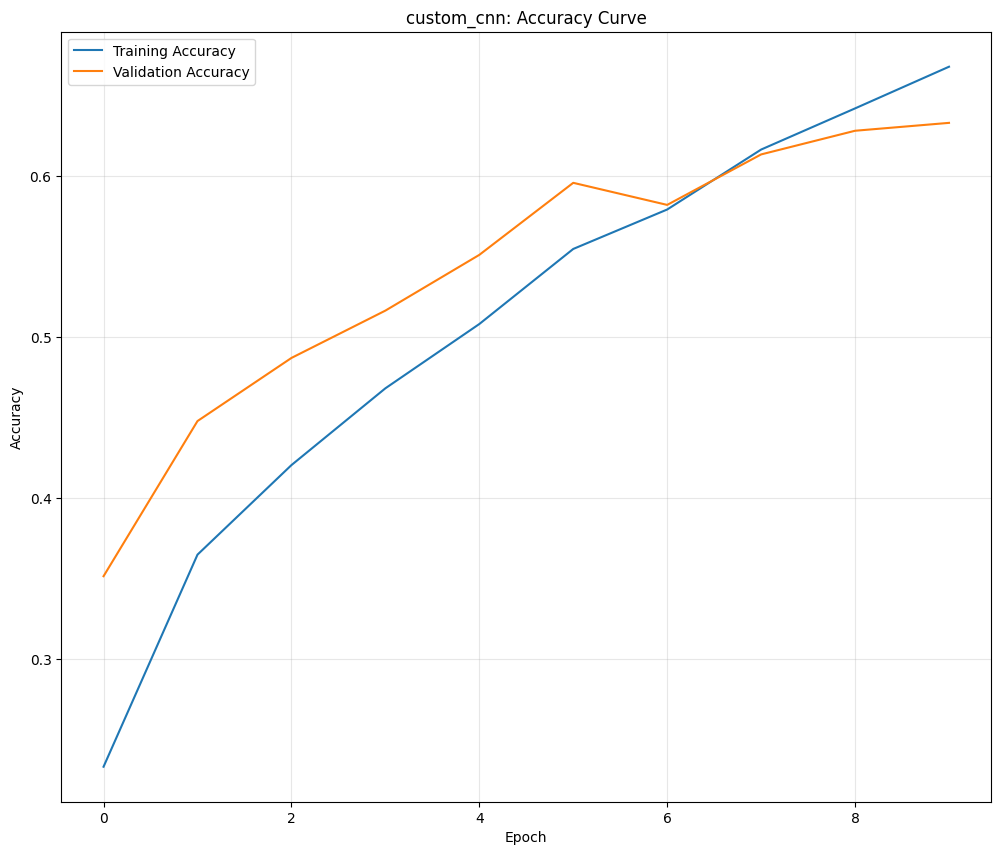

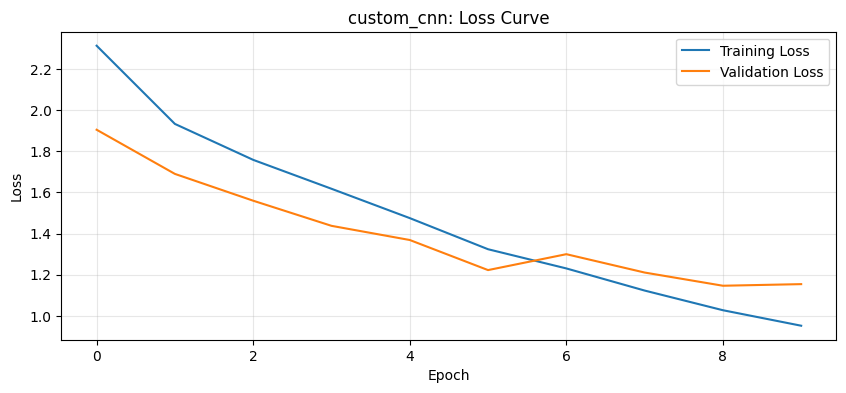

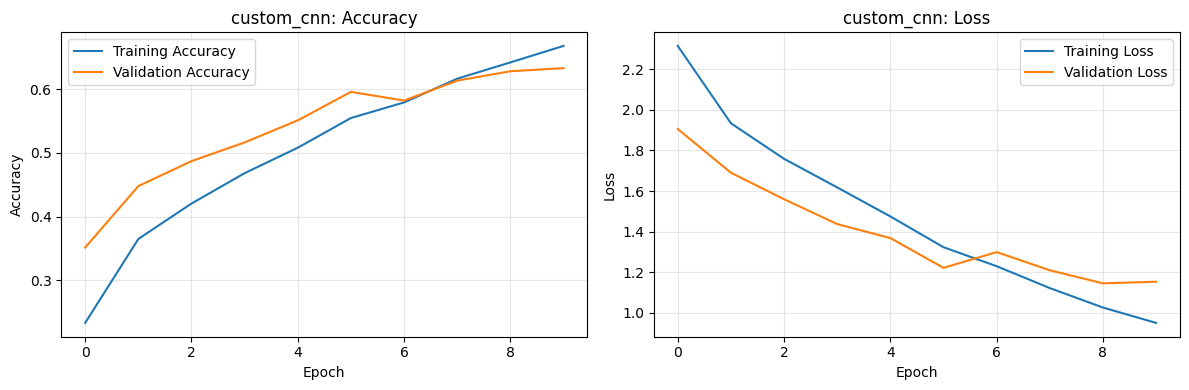

In [8]:
# ============================================================
# 8. MODEL 1: CUSTOM CNN
# ============================================================

def build_custom_cnn():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="input_layer"),

        layers.Conv2D(32, (3, 3), activation="relu", name="conv1"),
        layers.MaxPooling2D((2, 2), name="pool1"),

        layers.Conv2D(64, (3, 3), activation="relu", name="conv2"),
        layers.MaxPooling2D((2, 2), name="pool2"),

        layers.Conv2D(128, (3, 3), activation="relu", name="conv3"),
        layers.MaxPooling2D((2, 2), name="pool3"),

        layers.Conv2D(128, (3, 3), activation="relu", name="conv4"),
        layers.MaxPooling2D((2, 2), name="pool4"),

        layers.Flatten(name="flatten"),
        layers.Dense(128, activation="relu", name="dense1"),
        layers.Dropout(0.5, name="dropout"),
        layers.Dense(16, activation="softmax", name="output")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

custom_cnn = build_custom_cnn()
custom_cnn.summary()
save_model_architecture_table(custom_cnn, "custom_cnn")

custom_history, custom_training_time = train_with_time(
    custom_cnn,
    custom_train_ds,
    custom_val_ds,
    "custom_cnn",
    epochs=EPOCHS
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 16)             │        20,496 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,278,480 (8.69 MB)

 Trainable params: 20,496 (80.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 36s 64ms/step - accuracy: 0.3038 - loss: 2.2569 - val_accuracy: 0.5463 - val_loss: 1.5283
Epoch 2/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5243 - loss: 1.5131 - val_accuracy: 0.6384 - val_loss: 1.1911
Epoch 3/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.6074 - loss: 1.2564 - val_accuracy: 0.6789 - val_loss: 1.0429
Epoch 4/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.6487 - loss: 1.1147 - val_accuracy: 0.7086 - val_loss: 0.9563
Epoch 5/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.6738 - loss: 1.0273 - val_accuracy: 0.7177 - val_loss: 0.8968
Epoch 6/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.6940 - loss: 0.9605 - val_accuracy: 0.7291 - val_loss: 0.8529
Epoch 7/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.7036 - loss: 0.9135 - val_accuracy: 0.7366 - val_loss: 0.8199
Epoch 8/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.7197 - loss: 0.8719 - 

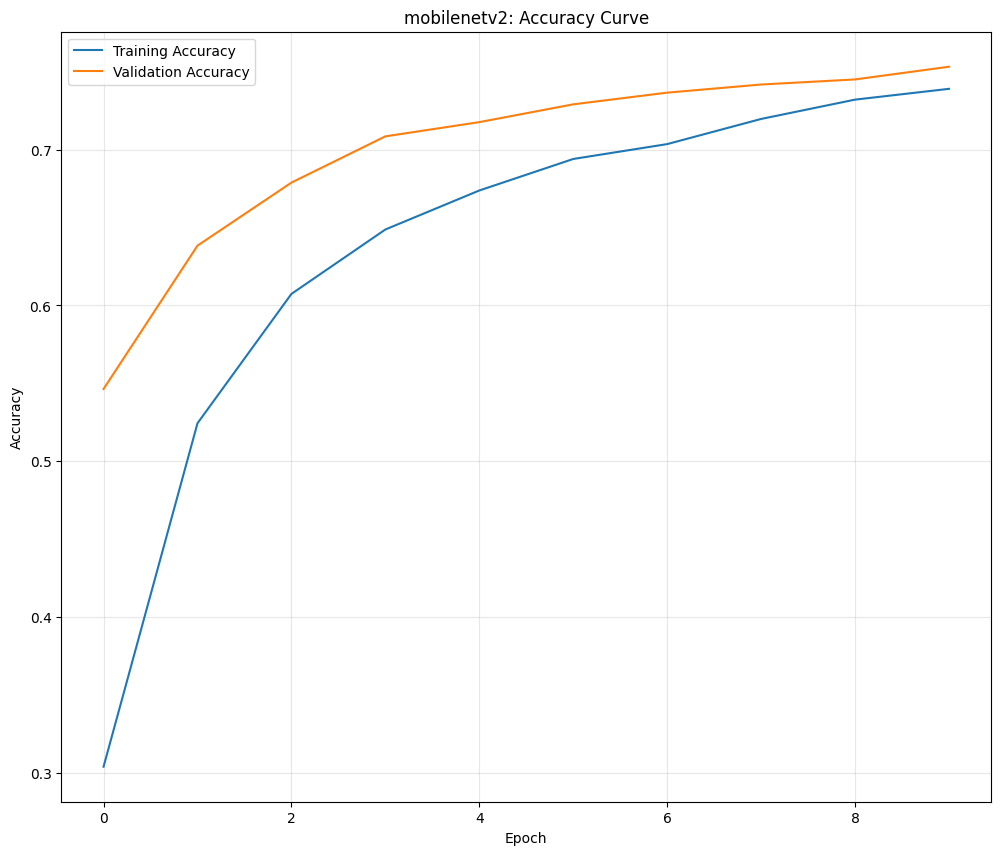

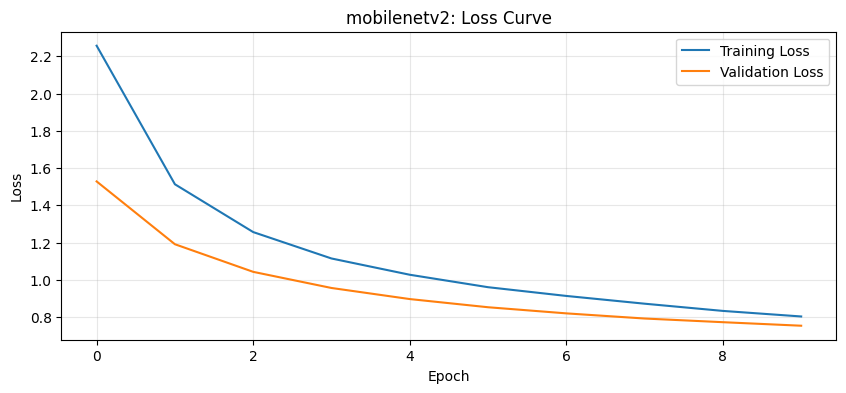

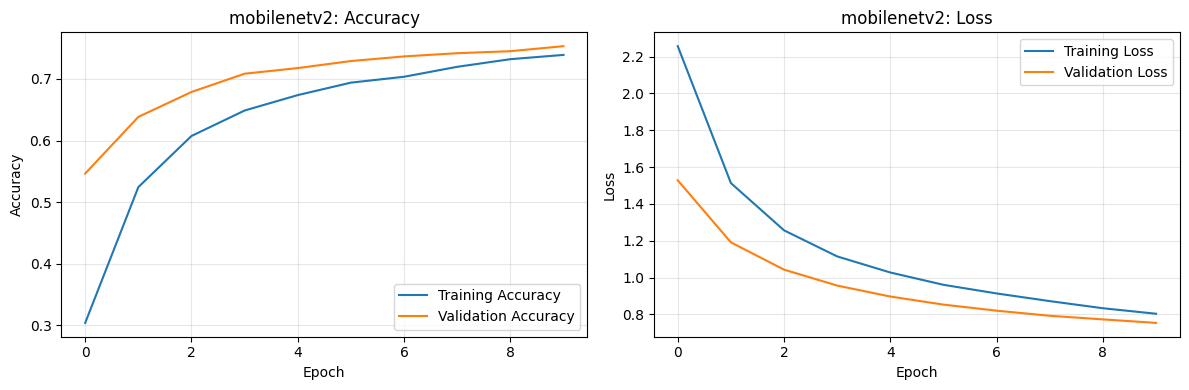

In [9]:
# ============================================================
# 9. MODEL 2: MOBILENETV2 TRANSFER LEARNING
# ============================================================

def build_mobilenetv2():
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="input_layer")
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = layers.Dropout(0.3, name="dropout")(x)
    outputs = layers.Dense(16, activation="softmax", name="output")(x)

    model = models.Model(inputs, outputs, name="MobileNetV2_transfer_learning")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base_model

mobilenet_model, mobilenet_base = build_mobilenetv2()
mobilenet_model.summary()
save_model_architecture_table(mobilenet_model, "mobilenetv2")

mobilenet_history, mobilenet_training_time = train_with_time(
    mobilenet_model,
    mobilenet_train_ds,
    mobilenet_val_ds,
    "mobilenetv2",
    epochs=EPOCHS
)

if RUN_FINE_TUNING:
    mobilenet_base.trainable = True
    for layer in mobilenet_base.layers[:-30]:
        layer.trainable = False

    mobilenet_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    mobilenet_ft_history, mobilenet_ft_time = train_with_time(
        mobilenet_model,
        mobilenet_train_ds,
        mobilenet_val_ds,
        "mobilenetv2_finetuned",
        epochs=FINE_TUNE_EPOCHS
    )
    mobilenet_training_time += mobilenet_ft_time

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ResNet50_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 16)             │        32,784 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,620,496 (90.11 MB)

 Trainable params: 32,784 (128.06 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 45s 89ms/step - accuracy: 0.3145 - loss: 2.2808 - val_accuracy: 0.5339 - val_loss: 1.4966
Epoch 2/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - accuracy: 0.5313 - loss: 1.4712 - val_accuracy: 0.6495 - val_loss: 1.1730
Epoch 3/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - accuracy: 0.6186 - loss: 1.2046 - val_accuracy: 0.6909 - val_loss: 1.0232
Epoch 4/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.6705 - loss: 1.0496 - val_accuracy: 0.7196 - val_loss: 0.9359
Epoch 5/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - accuracy: 0.6935 - loss: 0.9559 - val_accuracy: 0.7356 - val_loss: 0.8713
Epoch 6/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - accuracy: 0.7227 - loss: 0.8861 - val_accuracy: 0.7490 - val_loss: 0.8250
Epoch 7/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - accuracy: 0.7359 - loss: 0.8354 - val_accuracy: 0.7582 - val_loss: 0.7883
Epoch 8/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - accuracy: 0.7514 - loss: 0.7913 - 

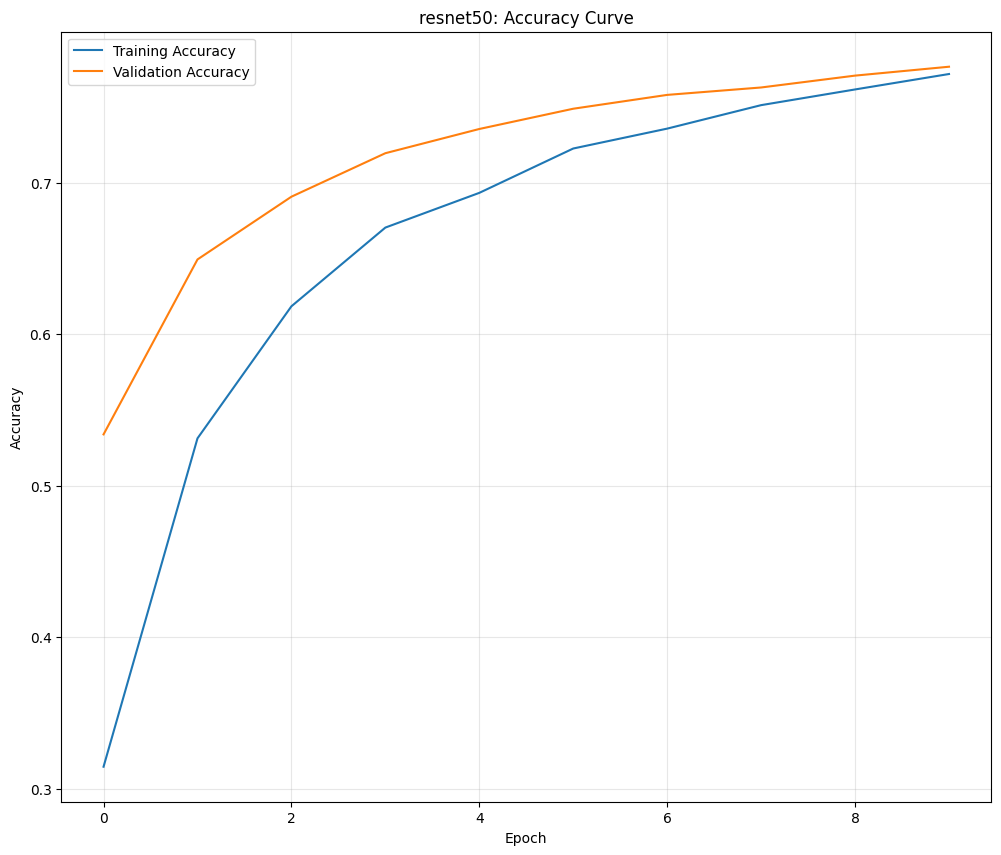

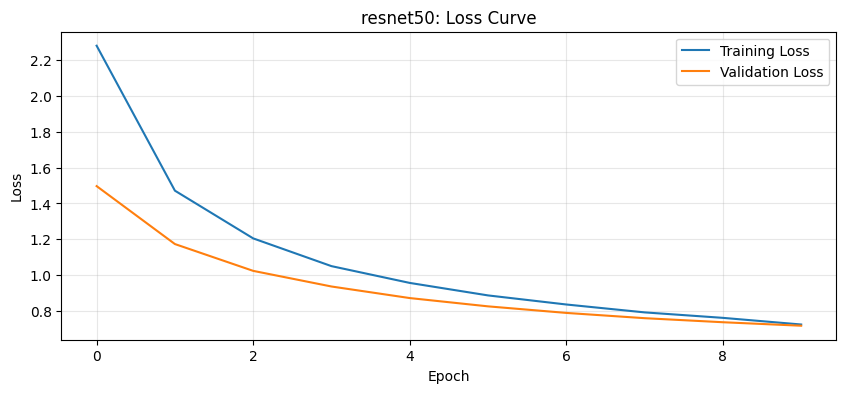

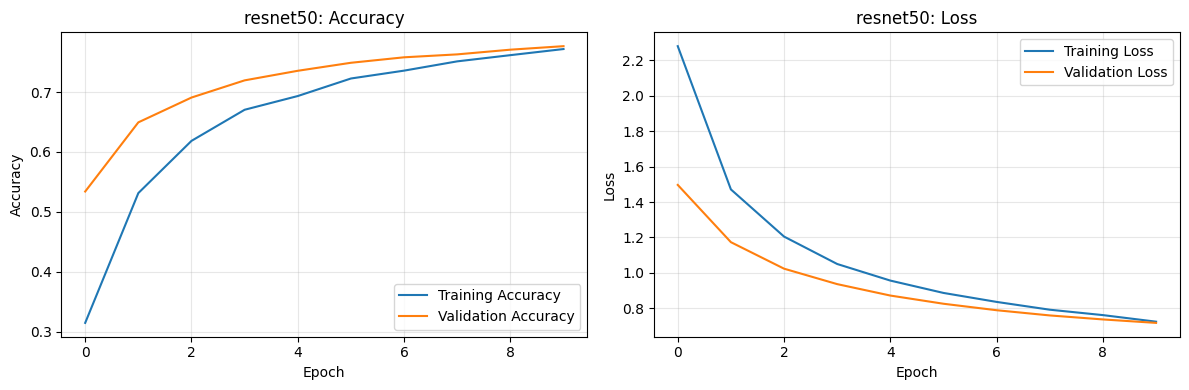

In [10]:
# ============================================================
# 10. MODEL 3: RESNET50 TRANSFER LEARNING
# ============================================================

def build_resnet50():
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="input_layer")
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = layers.Dropout(0.3, name="dropout")(x)
    outputs = layers.Dense(16, activation="sigmoid", name="output")(x)

    model = models.Model(inputs, outputs, name="ResNet50_transfer_learning")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base_model

resnet_model, resnet_base = build_resnet50()
resnet_model.summary()
save_model_architecture_table(resnet_model, "resnet50")

resnet_history, resnet_training_time = train_with_time(
    resnet_model,
    resnet_train_ds,
    resnet_val_ds,
    "resnet50",
    epochs=EPOCHS
)

if RUN_FINE_TUNING:
    resnet_base.trainable = True
    for layer in resnet_base.layers[:-30]:
        layer.trainable = False

    resnet_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    resnet_ft_history, resnet_ft_time = train_with_time(
        resnet_model,
        resnet_train_ds,
        resnet_val_ds,
        "resnet50_finetuned",
        epochs=FINE_TUNE_EPOCHS
    )
    resnet_training_time += resnet_ft_time


Evaluating: custom_cnn
start getting predictions
finished getting predictions
!!!!======!!!!!
['0.Kena_(Commplina_benghalensio)', '1..Lavhala_(Cyperus_Rotundus)', '10.Gajar_gavat_(Parthenium hysterophorus)', '11.Graceful_Sandmart_(Euphorbia hypericifolia)', '12.Sicklepod_(Senna obtusifolia)', '13.Harali_(Cynodon_dactylon)', '14.Dwarf_cassia_(Chamaecrista pumila)', '15.Punarnava _(Boerhaavia diffusa)', '2.Lamber_Quarter_plant(Chenopodium )', '3.Little_Mallow(Malva parviflora)', '4.Moti_dudhi(Euphorbia_geneculata_L)', '5.Obscure_morning _glory(Ipomoea obscura)', '6.Asian_Pigeonwings_(Clitoria Ternatea)', '7.Bilayat_(Mexicana_Argemone)', '8.Choti_dudhi_(Euphorbia_hirta)', '9.Digitaria_SP_(Digitaria Sanguinalis )']
!!!!======!!!!!
(3821,) y_true =  [ 0  0  0 ... 15 15 15]
(3821,) y_pred =  [ 0 11  0 ... 15 10 15]
(3821, 16) y_true =  [ 0  0  0 ... 15 15 15]


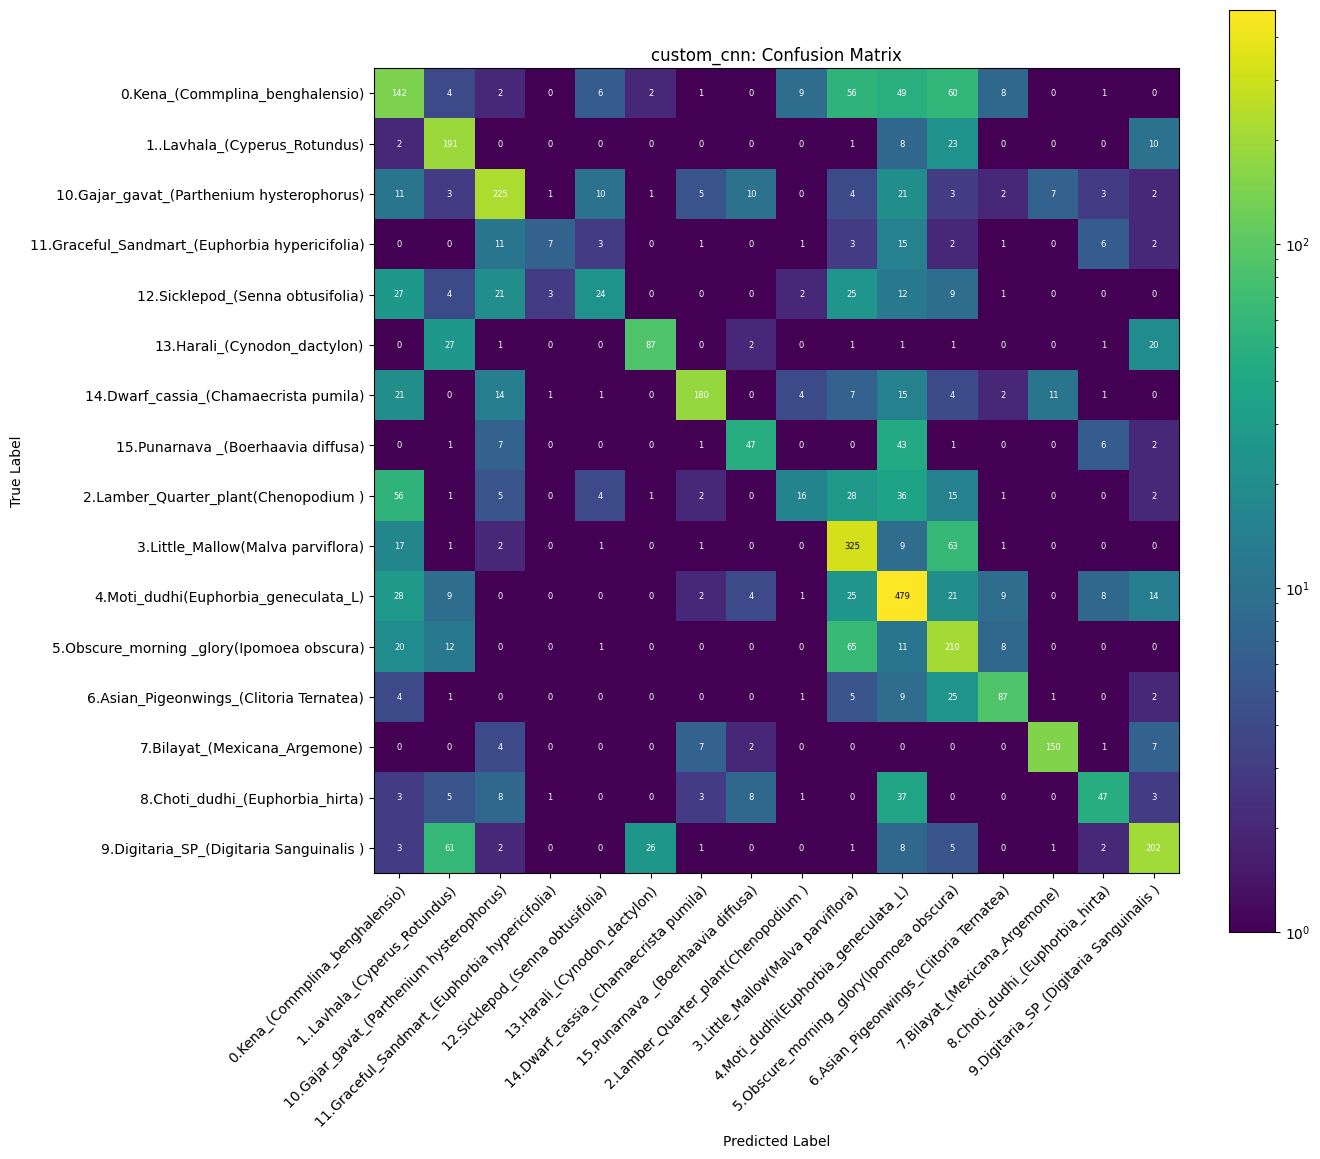


Evaluating: mobilenetv2
start getting predictions
finished getting predictions
!!!!======!!!!!
['0.Kena_(Commplina_benghalensio)', '1..Lavhala_(Cyperus_Rotundus)', '10.Gajar_gavat_(Parthenium hysterophorus)', '11.Graceful_Sandmart_(Euphorbia hypericifolia)', '12.Sicklepod_(Senna obtusifolia)', '13.Harali_(Cynodon_dactylon)', '14.Dwarf_cassia_(Chamaecrista pumila)', '15.Punarnava _(Boerhaavia diffusa)', '2.Lamber_Quarter_plant(Chenopodium )', '3.Little_Mallow(Malva parviflora)', '4.Moti_dudhi(Euphorbia_geneculata_L)', '5.Obscure_morning _glory(Ipomoea obscura)', '6.Asian_Pigeonwings_(Clitoria Ternatea)', '7.Bilayat_(Mexicana_Argemone)', '8.Choti_dudhi_(Euphorbia_hirta)', '9.Digitaria_SP_(Digitaria Sanguinalis )']
!!!!======!!!!!
(3821,) y_true =  [ 0  0  0 ... 15 15 15]
(3821,) y_pred =  [0 0 0 ... 6 5 1]
(3821, 16) y_true =  [ 0  0  0 ... 15 15 15]


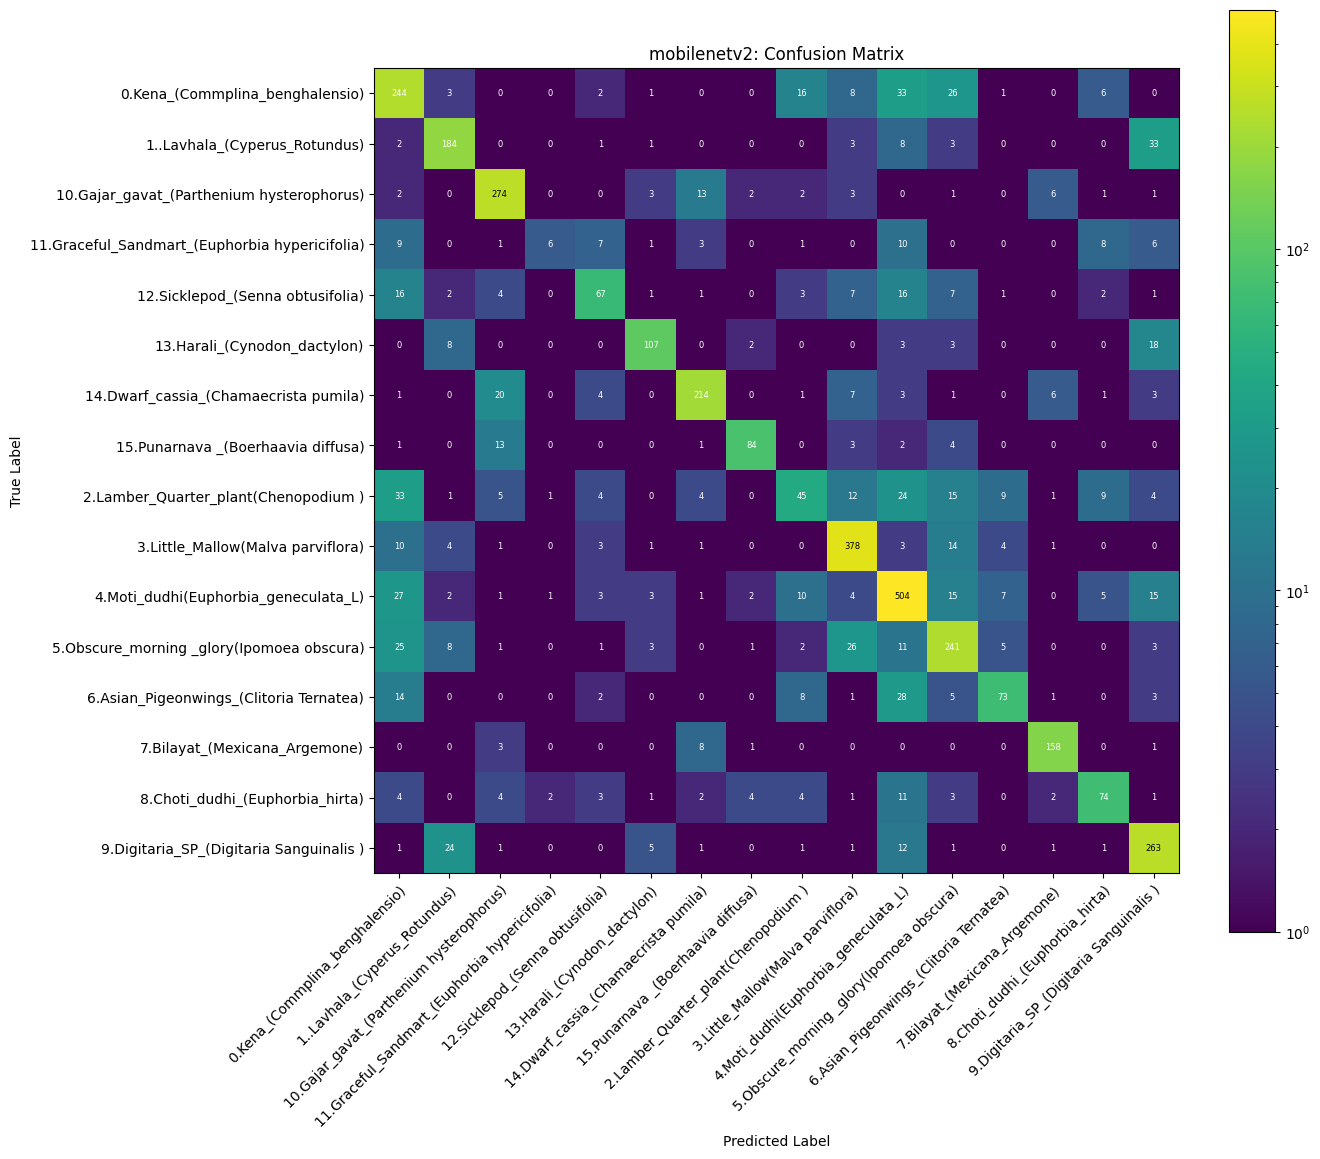


Evaluating: resnet50
start getting predictions
finished getting predictions
!!!!======!!!!!
['0.Kena_(Commplina_benghalensio)', '1..Lavhala_(Cyperus_Rotundus)', '10.Gajar_gavat_(Parthenium hysterophorus)', '11.Graceful_Sandmart_(Euphorbia hypericifolia)', '12.Sicklepod_(Senna obtusifolia)', '13.Harali_(Cynodon_dactylon)', '14.Dwarf_cassia_(Chamaecrista pumila)', '15.Punarnava _(Boerhaavia diffusa)', '2.Lamber_Quarter_plant(Chenopodium )', '3.Little_Mallow(Malva parviflora)', '4.Moti_dudhi(Euphorbia_geneculata_L)', '5.Obscure_morning _glory(Ipomoea obscura)', '6.Asian_Pigeonwings_(Clitoria Ternatea)', '7.Bilayat_(Mexicana_Argemone)', '8.Choti_dudhi_(Euphorbia_hirta)', '9.Digitaria_SP_(Digitaria Sanguinalis )']
!!!!======!!!!!
(3821,) y_true =  [ 0  0  0 ... 15 15 15]
(3821,) y_pred =  [ 0  0  0 ... 15  5 15]
(3821, 16) y_true =  [ 0  0  0 ... 15 15 15]


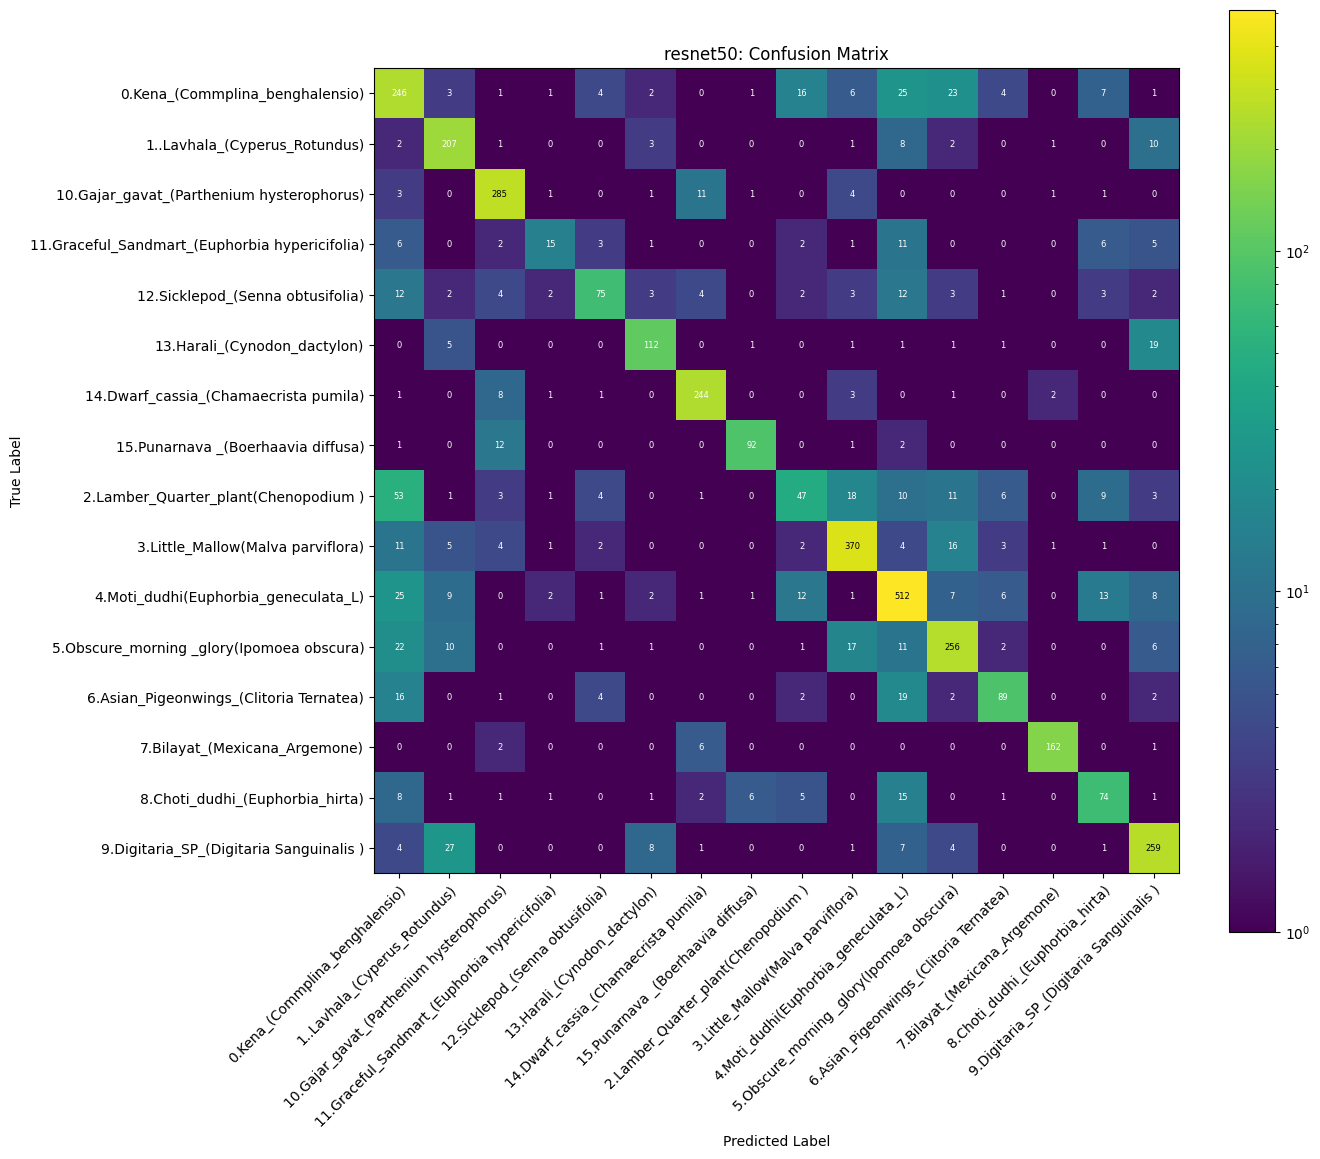

,model,accuracy,precision,recall,f1_score,training_time_seconds,training_time_minutes,total_parameters,trainable_parameters,non_trainable_parameters
0,custom_cnn,0.633080,0.635751,0.633080,0.617929,154.197623,2.569960,2602320,2602320,0
1,mobilenetv2,0.763151,0.756886,0.763151,0.754233,169.579704,2.826328,2278480,20496,2257984
2,resnet50,0.796912,0.793356,0.796912,0.791048,287.393270,4.789888,23620496,32784,23587712


In [30]:
# ============================================================
# 11. MODEL EVALUATION
# ============================================================

evaluation_records = []
prediction_cache = {}

models_info = [
    ("custom_cnn", custom_cnn, custom_test_ds, custom_training_time),
    ("mobilenetv2", mobilenet_model, mobilenet_test_ds, mobilenet_training_time),
    ("resnet50", resnet_model, resnet_test_ds, resnet_training_time)
]

for model_name, model, test_ds, train_time in models_info:
    print("\nEvaluating:", model_name)
    result, y_true, y_pred, y_prob = evaluate_model(model, test_ds, model_name)
    total_params, trainable_params, non_trainable_params = count_model_parameters(model)

    result.update({
        "training_time_seconds": train_time,
        "training_time_minutes": train_time / 60,
        "total_parameters": total_params,
        "trainable_parameters": trainable_params,
        "non_trainable_parameters": non_trainable_params
    })

    evaluation_records.append(result)
    prediction_cache[model_name] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    plot_confusion_matrix_pdf(y_true, y_pred, model_name)

final_results_df = pd.DataFrame(evaluation_records)
final_results_df.to_csv(TABLE_DIR / "final_model_comparison.csv", index=False)
display(final_results_df)

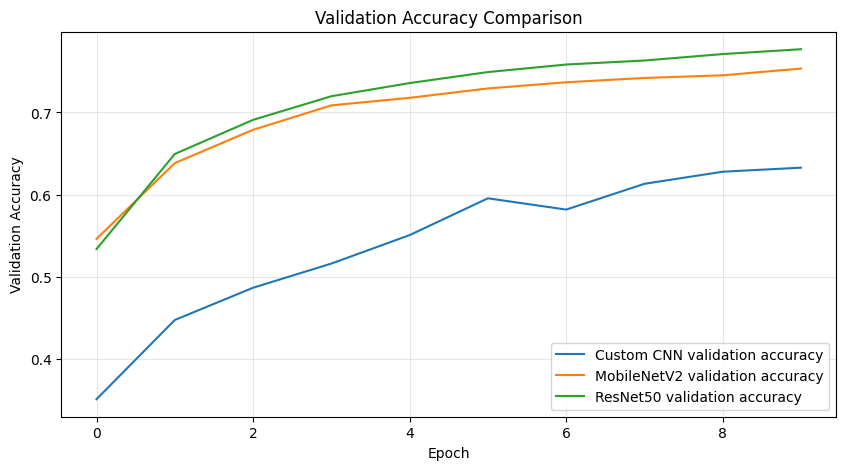

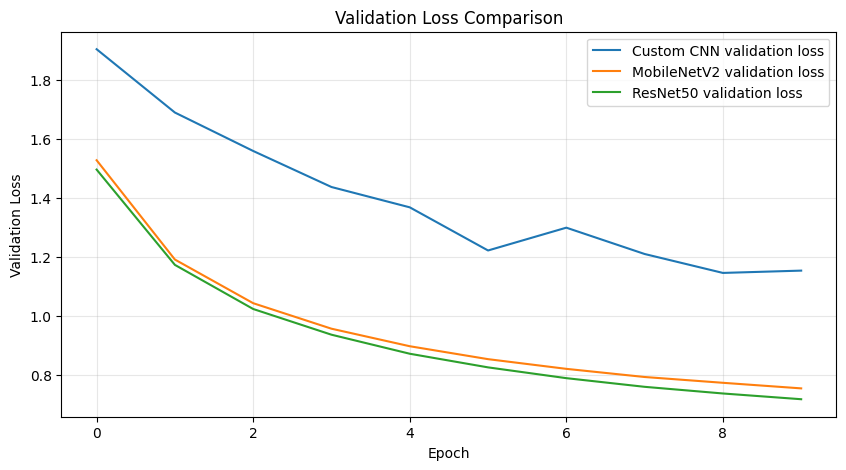

In [12]:
# ============================================================
# 12. COMBINED TRAINING CURVE COMPARISON
# ============================================================

def plot_combined_curves(histories_dict):
    plt.figure(figsize=(10, 5))
    for model_name, history in histories_dict.items():
        plt.plot(history.history.get("val_accuracy", []), label=f"{model_name} validation accuracy")
    plt.title("Validation Accuracy Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(FIG_DIR / "validation_accuracy_comparison.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 5))
    for model_name, history in histories_dict.items():
        plt.plot(history.history.get("val_loss", []), label=f"{model_name} validation loss")
    plt.title("Validation Loss Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(FIG_DIR / "validation_loss_comparison.pdf", format="pdf", bbox_inches="tight")
    plt.show()

plot_combined_curves({
    "Custom CNN": custom_history,
    "MobileNetV2": mobilenet_history,
    "ResNet50": resnet_history
})

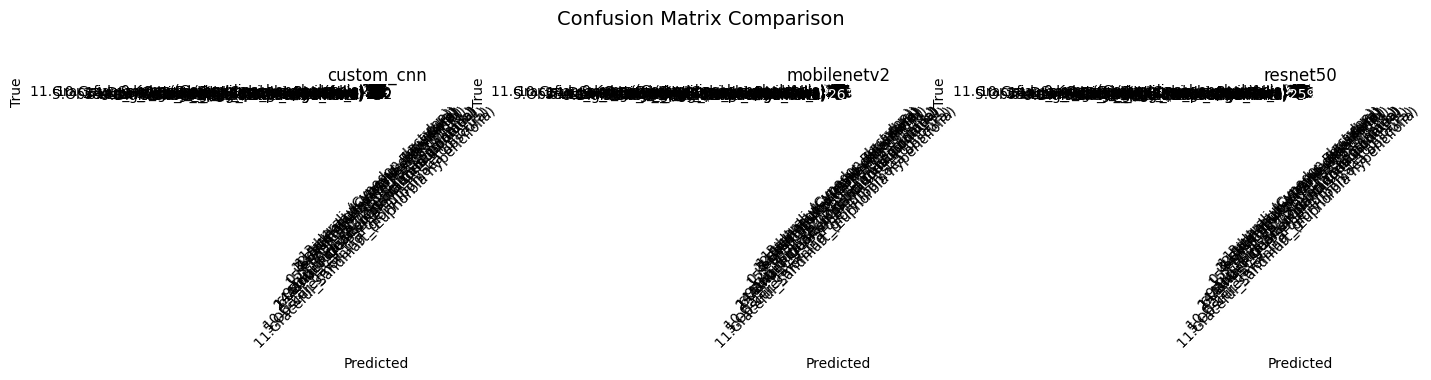

In [31]:
# ============================================================
# 13. COMBINED CONFUSION MATRIX COMPARISON
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (model_name, _, _, _) in zip(axes, models_info):
    y_true = prediction_cache[model_name]["y_true"]
    y_pred = prediction_cache[model_name]["y_pred"]
    cm = confusion_matrix(y_true, y_pred)

    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(model_name)
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > threshold else "black"
            )

fig.suptitle("Confusion Matrix Comparison", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix_comparison.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [14]:
# ============================================================
# 14. HELPER FUNCTIONS FOR IMAGE-LEVEL ANALYSIS
# ============================================================

def load_test_image_paths():
    if TEST_DIR is None:
        source_dir = TRAIN_DIR
    else:
        source_dir = TEST_DIR

    records = []
    for class_idx, class_name in enumerate(sorted([p.name for p in Path(source_dir).iterdir() if p.is_dir()])):
        class_dir = Path(source_dir) / class_name
        for img_path in class_dir.rglob("*"):
            if img_path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append({
                    "path": str(img_path),
                    "true_label_name": class_name,
                    "true_label_index": class_idx
                })
    return pd.DataFrame(records)

test_image_df = load_test_image_paths().sort_values("path").reset_index(drop=True)
test_image_df.to_csv(TABLE_DIR / "test_image_paths.csv", index=False)
display(test_image_df.head())

def preprocess_single_image(img_path, preprocess_type):
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img)
    arr_batch = np.expand_dims(arr.copy(), axis=0)

    if preprocess_type == "custom":
        arr_batch = arr_batch / 255.0
    elif preprocess_type == "mobilenet":
        arr_batch = mobilenet_preprocess(arr_batch)
    elif preprocess_type == "resnet":
        arr_batch = resnet_preprocess(arr_batch)
    else:
        raise ValueError("Unknown preprocess type")

    return arr.astype(np.uint8), arr_batch

def predict_single(model, img_path, preprocess_type):
    original, arr_batch = preprocess_single_image(img_path, preprocess_type)
    prob = float(model.predict(arr_batch, verbose=0).ravel()[0])
    pred_idx = int(prob >= 0.5)
    confidence = prob if pred_idx == 1 else 1 - prob
    return pred_idx, prob, confidence

model_preprocess_map = {
    "custom_cnn": "custom",
    "mobilenetv2": "mobilenet",
    "resnet50": "resnet"
}

model_object_map = {
    "custom_cnn": custom_cnn,
    "mobilenetv2": mobilenet_model,
    "resnet50": resnet_model
}

NameError: name 'IMAGE_EXTENSIONS' is not defined

In [ ]:
# ============================================================
# 15. SELECT CORRECT AND INCORRECT EXAMPLES
# ============================================================

# We select examples based on MobileNetV2 predictions because it usually performs well.
# The same images will then be explained across all three models.

selection_model_name = "mobilenetv2"
selection_model = model_object_map[selection_model_name]
selection_preprocess = model_preprocess_map[selection_model_name]

selection_records = []
for _, row in test_image_df.iterrows():
    pred_idx, prob, conf = predict_single(selection_model, row["path"], selection_preprocess)
    selection_records.append({
        "path": row["path"],
        "true_label_index": int(row["true_label_index"]),
        "true_label_name": row["true_label_name"],
        "predicted_label_index": pred_idx,
        "predicted_label_name": class_names[pred_idx],
        "probability_dog_or_class_1": prob,
        "confidence": conf,
        "is_correct": pred_idx == int(row["true_label_index"])
    })

selection_df = pd.DataFrame(selection_records)
selection_df.to_csv(TABLE_DIR / "single_image_prediction_selection.csv", index=False)

correct_examples = selection_df[selection_df["is_correct"]].sort_values("confidence", ascending=False).head(3)
incorrect_examples = selection_df[~selection_df["is_correct"]].sort_values("confidence", ascending=False).head(3)

# If there are fewer incorrect examples, choose lower-confidence correct examples for demonstration.
if len(incorrect_examples) == 0:
    incorrect_examples = selection_df[selection_df["is_correct"]].sort_values("confidence", ascending=True).head(3)
    print("No misclassified images found by the selection model. Using low-confidence correct images instead.")

display(correct_examples)
display(incorrect_examples)

In [ ]:
# ============================================================
# 16. PLOT CORRECT AND INCORRECT PREDICTION EXAMPLES
# ============================================================

def plot_prediction_examples(examples_df, filename, title):
    plt.figure(figsize=(12, 4))
    for i, (_, row) in enumerate(examples_df.iterrows()):
        img = tf.keras.utils.load_img(row["path"], target_size=IMG_SIZE)
        plt.subplot(1, len(examples_df), i + 1)
        plt.imshow(img)
        plt.title(
            f"True: {row['true_label_name']}\nPred: {row['predicted_label_name']}\nConf: {row['confidence']:.2f}"
        )
        plt.axis("off")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, format="pdf", bbox_inches="tight")
    plt.show()

plot_prediction_examples(
    correct_examples,
    "correct_prediction_examples.pdf",
    "Correct Prediction Examples"
)

plot_prediction_examples(
    incorrect_examples,
    "incorrect_prediction_examples.pdf",
    "Incorrect or Low-Confidence Prediction Examples"
)

In [ ]:
# ============================================================
# 17. GRAD-CAM IMPLEMENTATION
# ============================================================

def find_last_conv_layer_name(model):
    # Search nested models first, because MobileNetV2 and ResNet50 are nested inside the transfer model.
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.Model):
            for sublayer in reversed(layer.layers):
                if isinstance(sublayer, tf.keras.layers.Conv2D):
                    return sublayer.name
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found for Grad-CAM.")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Handles both Sequential and Functional models, including nested transfer-learning bases.
    try:
        last_conv_layer = model.get_layer(last_conv_layer_name)
        grad_model = tf.keras.models.Model(
            inputs=model.inputs,
            outputs=[last_conv_layer.output, model.output]
        )
    except Exception:
        # Nested model case
        nested_model = None
        for layer in model.layers:
            if isinstance(layer, tf.keras.Model):
                try:
                    nested_model = layer
                    last_conv_layer = nested_model.get_layer(last_conv_layer_name)
                    break
                except Exception:
                    continue

        if nested_model is None:
            raise ValueError(f"Could not locate layer {last_conv_layer_name}")

        # Build a model that outputs the nested conv activation and the final prediction.
        grad_model = tf.keras.models.Model(
            inputs=model.inputs,
            outputs=[last_conv_layer.output, model.output]
        )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    if grads is None:
        raise ValueError("Gradients are None. Could not compute Grad-CAM.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.math.reduce_max(heatmap)
    if max_val == 0:
        return np.zeros_like(heatmap.numpy())
    heatmap /= max_val

    return heatmap.numpy()

def overlay_heatmap(original_img, heatmap, alpha=0.4):
    original_img = original_img.astype(np.uint8)

    if CV2_AVAILABLE:
        heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
        heatmap_uint8 = np.uint8(255 * heatmap_resized)
        heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        overlay = np.uint8(heatmap_color * alpha + original_img * (1 - alpha))
    else:
        heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
        heatmap_color = plt.cm.jet(heatmap_resized)[:, :, :3] * 255
        overlay = np.uint8(heatmap_color * alpha + original_img * (1 - alpha))

    return overlay

last_conv_layers = {}
for model_name, model in model_object_map.items():
    layer_name = find_last_conv_layer_name(model)
    last_conv_layers[model_name] = layer_name
    print(model_name, "last conv layer:", layer_name)

pd.DataFrame([
    {"model": k, "last_conv_layer_for_gradcam": v}
    for k, v in last_conv_layers.items()
]).to_csv(TABLE_DIR / "gradcam_last_conv_layers.csv", index=False)

In [ ]:
# ============================================================
# 18. GENERATE GRAD-CAM COMPARISON FIGURES
# ============================================================

def generate_gradcam_comparison(examples_df, output_filename, title):
    model_names = ["custom_cnn", "mobilenetv2", "resnet50"]
    n_rows = len(examples_df)
    n_cols = 1 + len(model_names)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, (_, row) in enumerate(examples_df.iterrows()):
        img_path = row["path"]
        original_img_for_display = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
        original_img_for_display = tf.keras.utils.img_to_array(original_img_for_display).astype(np.uint8)

        axes[row_idx, 0].imshow(original_img_for_display)
        axes[row_idx, 0].set_title(
            f"Original\nTrue: {row['true_label_name']}"
        )
        axes[row_idx, 0].axis("off")

        for col_idx, model_name in enumerate(model_names, start=1):
            model = model_object_map[model_name]
            preprocess_type = model_preprocess_map[model_name]

            original_img, img_array = preprocess_single_image(img_path, preprocess_type)
            pred_idx, prob, conf = predict_single(model, img_path, preprocess_type)

            try:
                heatmap = make_gradcam_heatmap(
                    img_array,
                    model,
                    last_conv_layers[model_name]
                )
                overlay = overlay_heatmap(original_img, heatmap)
                axes[row_idx, col_idx].imshow(overlay)
            except Exception as e:
                axes[row_idx, col_idx].imshow(original_img)
                axes[row_idx, col_idx].text(
                    10, 20, f"Grad-CAM failed:\n{str(e)[:60]}",
                    color="red", fontsize=8, bbox=dict(facecolor="white", alpha=0.8)
                )

            axes[row_idx, col_idx].set_title(
                f"{model_name}\nPred: {class_names[pred_idx]}\nConf: {conf:.2f}"
            )
            axes[row_idx, col_idx].axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.savefig(FIG_DIR / output_filename, format="pdf", bbox_inches="tight")
    plt.show()

generate_gradcam_comparison(
    correct_examples,
    "gradcam_correct_predictions.pdf",
    "Grad-CAM: Correct Prediction Examples"
)

generate_gradcam_comparison(
    incorrect_examples,
    "gradcam_misclassified_predictions.pdf",
    "Grad-CAM: Misclassified or Low-Confidence Examples"
)

In [ ]:
# ============================================================
# 19. SHAP EXPLANATIONS
# ============================================================

# SHAP for images can be slow. This section uses a small background set and a few selected images.
# If SHAP fails due to package/version constraints, the notebook will save a CSV note and continue.

def get_numpy_batch_from_dataset(ds, max_images):
    images_list = []
    labels_list = []
    for images, labels in ds:
        images_list.append(images.numpy())
        labels_list.append(labels.numpy())
        if sum(x.shape[0] for x in images_list) >= max_images:
            break
    images = np.concatenate(images_list, axis=0)[:max_images]
    labels = np.concatenate(labels_list, axis=0)[:max_images]
    return images, labels

def run_shap_for_model(model, train_ds, test_ds, model_name, max_background=20, max_explain=3):
    if not SHAP_AVAILABLE or not RUN_SHAP:
        return {"model": model_name, "status": "Skipped", "reason": "SHAP unavailable or RUN_SHAP=False"}

    try:
        background_images, _ = get_numpy_batch_from_dataset(train_ds, max_background)
        explain_images, explain_labels = get_numpy_batch_from_dataset(test_ds, max_explain)

        # GradientExplainer is usually more practical for deep learning models in teaching demos.
        explainer = shap.GradientExplainer(model, background_images)
        shap_values = explainer.shap_values(explain_images)

        # Convert output structure into a usable array.
        if isinstance(shap_values, list):
            shap_arr = shap_values[0]
        else:
            shap_arr = shap_values

        # Plot simple SHAP magnitude maps beside original images.
        fig, axes = plt.subplots(max_explain, 3, figsize=(10, 4 * max_explain))
        if max_explain == 1:
            axes = np.expand_dims(axes, axis=0)

        for i in range(max_explain):
            img = explain_images[i]

            # Convert image back approximately for display.
            display_img = img.copy()
            display_img = display_img - display_img.min()
            if display_img.max() > 0:
                display_img = display_img / display_img.max()

            shap_map = np.mean(np.abs(shap_arr[i]), axis=-1)

            pred_prob = float(model.predict(np.expand_dims(explain_images[i], axis=0), verbose=0).ravel()[0])
            pred_idx = int(pred_prob >= 0.5)
            conf = pred_prob if pred_idx == 1 else 1 - pred_prob

            axes[i, 0].imshow(display_img)
            axes[i, 0].set_title(f"Original\nTrue: {class_names[int(explain_labels[i][0])]}")
            axes[i, 0].axis("off")

            axes[i, 1].imshow(shap_map)
            axes[i, 1].set_title("SHAP magnitude map")
            axes[i, 1].axis("off")

            axes[i, 2].imshow(display_img)
            axes[i, 2].imshow(shap_map, alpha=0.45)
            axes[i, 2].set_title(f"Overlay\nPred: {class_names[pred_idx]} | Conf: {conf:.2f}")
            axes[i, 2].axis("off")

        fig.suptitle(f"SHAP Explanation Examples: {model_name}", fontsize=14)
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"shap_{model_name}_examples.pdf", format="pdf", bbox_inches="tight")
        plt.show()

        return {"model": model_name, "status": "Completed", "reason": ""}

    except Exception as e:
        print(f"SHAP failed for {model_name}: {e}")
        return {"model": model_name, "status": "Failed", "reason": str(e)}

shap_status_records = []

shap_status_records.append(run_shap_for_model(
    custom_cnn,
    custom_train_ds,
    custom_test_ds,
    "custom_cnn",
    SHAP_BACKGROUND_IMAGES,
    SHAP_EXPLAIN_IMAGES
))

shap_status_records.append(run_shap_for_model(
    mobilenet_model,
    mobilenet_train_ds,
    mobilenet_test_ds,
    "mobilenetv2",
    SHAP_BACKGROUND_IMAGES,
    SHAP_EXPLAIN_IMAGES
))

shap_status_records.append(run_shap_for_model(
    resnet_model,
    resnet_train_ds,
    resnet_test_ds,
    "resnet50",
    SHAP_BACKGROUND_IMAGES,
    SHAP_EXPLAIN_IMAGES
))

shap_status_df = pd.DataFrame(shap_status_records)
shap_status_df.to_csv(TABLE_DIR / "shap_status.csv", index=False)
display(shap_status_df)

In [ ]:
# ============================================================
# 20. QUALITATIVE EXPLAINABILITY RATINGS
# ============================================================

# Students may manually adjust these after visually inspecting Grad-CAM and SHAP outputs.
# Scale:
# 1 = unclear explanation
# 2 = weak explanation
# 3 = moderate explanation
# 4 = clear explanation
# 5 = highly meaningful explanation

explainability_ratings = pd.DataFrame([
    {
        "model": "custom_cnn",
        "gradcam_quality_score_1_to_5": 3,
        "shap_interpretability_score_1_to_5": 3,
        "explanation_note": "Custom CNN explanations may be less stable because features are learned only from the small dataset."
    },
    {
        "model": "mobilenetv2",
        "gradcam_quality_score_1_to_5": 4,
        "shap_interpretability_score_1_to_5": 4,
        "explanation_note": "MobileNetV2 usually provides efficient and meaningful explanations with lower computational cost."
    },
    {
        "model": "resnet50",
        "gradcam_quality_score_1_to_5": 4,
        "shap_interpretability_score_1_to_5": 4,
        "explanation_note": "ResNet50 may provide strong explanations but has higher computational complexity."
    }
])

explainability_ratings.to_csv(TABLE_DIR / "explainability_quality_ratings.csv", index=False)
display(explainability_ratings)

In [ ]:
# ============================================================
# 21. FINAL COMPARATIVE TABLE
# ============================================================

final_comparative_table = final_results_df.merge(
    explainability_ratings,
    on="model",
    how="left"
)

def build_overall_finding(row):
    if row["model"] == "custom_cnn":
        return "Baseline model trained from scratch; useful for understanding CNN design."
    if row["model"] == "mobilenetv2":
        return "Efficient transfer learning model with strong performance-cost trade-off."
    if row["model"] == "resnet50":
        return "Deeper transfer learning model with more parameters and higher computational cost."
    return ""

final_comparative_table["overall_finding"] = final_comparative_table.apply(build_overall_finding, axis=1)

final_comparative_table.to_csv(TABLE_DIR / "final_comparative_table.csv", index=False)
display(final_comparative_table)

In [ ]:
# ============================================================
# 22. RESEARCH QUESTION ANSWERS
# ============================================================

best_accuracy_model = final_results_df.sort_values("accuracy", ascending=False).iloc[0]
best_f1_model = final_results_df.sort_values("f1_score", ascending=False).iloc[0]

# A simple cost-performance score: F1 divided by log10(parameters).
cost_df = final_results_df.copy()
cost_df["cost_performance_score"] = cost_df["f1_score"] / np.log10(cost_df["total_parameters"])
best_tradeoff_model = cost_df.sort_values("cost_performance_score", ascending=False).iloc[0]

rq_answers = pd.DataFrame([
    {
        "research_question": "RQ1: How accurately does a custom CNN classify images from the selected dataset?",
        "answer": f"The Custom CNN achieved an accuracy of {final_results_df[final_results_df['model']=='custom_cnn']['accuracy'].values[0]:.4f}."
    },
    {
        "research_question": "RQ2: Does transfer learning using MobileNetV2 and ResNet50 improve classification performance compared with a custom CNN?",
        "answer": "Compare the accuracy and F1-score values of MobileNetV2 and ResNet50 against the Custom CNN in final_model_comparison.csv."
    },
    {
        "research_question": "RQ3: Which model provides the best trade-off between classification performance and computational cost?",
        "answer": f"Based on the simple F1/log10(parameters) score, the best trade-off model is {best_tradeoff_model['model']}."
    },
    {
        "research_question": "RQ4: Which image regions does each model focus on when making correct predictions, according to Grad-CAM?",
        "answer": "See gradcam_correct_predictions.pdf and inspect whether heatmaps focus on the animal face, body, fur, or background."
    },
    {
        "research_question": "RQ5: Do Grad-CAM visualizations reveal different attention patterns for custom CNN and transfer learning models?",
        "answer": "See gradcam_correct_predictions.pdf and gradcam_misclassified_predictions.pdf for side-by-side attention comparisons."
    },
    {
        "research_question": "RQ6: What do SHAP explanations reveal about the positive and negative visual evidence used by each model?",
        "answer": "See the SHAP PDF outputs and shap_status.csv. SHAP maps show influential regions for selected test images."
    },
    {
        "research_question": "RQ7: Can explainability methods help diagnose why certain images are misclassified?",
        "answer": "See gradcam_misclassified_predictions.pdf and incorrect_prediction_examples.pdf to determine whether models focused on irrelevant regions."
    }
])

rq_answers.to_csv(TABLE_DIR / "research_question_answers.csv", index=False)
display(rq_answers)

In [ ]:
# ============================================================
# 23. CREATE OUTPUT MANIFEST
# ============================================================

all_output_files = []
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        all_output_files.append({
            "file_name": p.name,
            "relative_path": str(p.relative_to(OUTPUT_DIR)),
            "full_path": str(p),
            "file_type": p.suffix
        })

manifest_df = pd.DataFrame(all_output_files)
manifest_df.to_csv(OUTPUT_DIR / "output_manifest.csv", index=False)
display(manifest_df)

print("\nNotebook completed.")
print("All outputs are saved in:", OUTPUT_DIR)
print("Figures:", FIG_DIR)
print("Tables:", TABLE_DIR)
print("Models:", MODEL_DIR)